In [ ]:
# This Block is referenced from Andrej Karpathy's micrograd project, which is a tiny autograd engine in Python. 
# It is used to demonstrate how backpropagation works in neural networks. The code defines a class called Value, 
# which represents a single scalar value and its gradient. The class includes methods for basic arithmetic operations, 
# as well as a method for computing the backward pass to calculate gradients. I have added the sigmoid function to the Value class.
# He modelled it after PyTorch's autograd system, which is why i find it important and easier to undertand.
# Importantly it is not vectorised so i will not be able to run larger epochs
# https://github.com/karpathy/micrograd/blob/master/micrograd/engine.py

import numpy as np
import random
import math

# seeding for reproducability
np.random.seed(42)
random.seed(42)
# not working in ipynb

class Value:

    # a Value represents a single scalar value and its gradient
    def __init__(self, data, _children=()):
        self.data = data
        self.grad = 0
        self._backward = lambda: None
        self._prev = set(_children)

    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other))

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other))

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    def __pow__(self, other):
        out = Value(self.data**other, (self,))

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ))

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
    
    def log(self):
        x = self.data
        out = Value(math.log(x), (self, ))

        def _backward():
            self.grad += (1 / x) * out.grad
        out._backward = _backward

        return out
    
    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,))

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out
    
    def sigmoid(self):
        x = self.data
        out = Value(1 / (1 + math.exp(-x)), (self, ))

        def _backward():
            s = out.data
            self.grad += (s * (1 - s)) * out.grad
        out._backward = _backward

        return out
    
    def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"
    
    def __neg__(self): # -self
        return self * -1
    
    def __sub__(self, other): # self - other
        return self + (-other)
    
    def __rsub__(self, other): # other - self
        return other + (-self)
    
    def __radd__(self, other): # other + self
        return self + other
    
    def __rmul__(self, other): # other * self
        return self * other
    
    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

In [2]:
# This Block is also referenced from Andrej Karpathy's micrograd project.
# Ive modified it to have the last layer implement a sigmoid activation function.
# https://github.com/karpathy/micrograd/blob/master/micrograd/nn.py

class Module:

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self):
        return []

class Neuron(Module):

    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act.sigmoid()

    def parameters(self):
        return self.w + [self.b]
    
    def __repr__(self):
        return f"{'Relu' if self.nonlin else 'Sigmoid'}Neuron({len(self.w)})"

class Layer(Module):

    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]
    
    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"


class MLP(Module):

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], nonlin=i!=len(nouts)-1) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    
    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"

In [ ]:
# This Block is also referenced from Andrej Karpathy's micrograd project.
# Its been referenced from a demo file he provided which ive modified into binary classifier neural network trainer class.
# https://github.com/karpathy/micrograd/blob/master/demo.ipynb 

from matplotlib.pylab import inf

class LogisticRegressionTrainer:
    
    def __init__(self, X, y, hidden_layers=[1]):
        self.X = X
        self.y = y
        self.hidden_layers = hidden_layers
        self.model = MLP(len(X[0]), hidden_layers)
        self.X_train, self.y_train, self.X_val, self.y_val, self.X_test, self.y_test = self.split_train_val_test()
        self.verbose = False
        self.Losses = []
        self.Accuracies = []

    def log(self, *args, **kwargs):
        if self.verbose:
            print(*args, **kwargs)

    def loss(self, alpha = 1e-4, batch_size=None):
        
        if batch_size is None:
            Xb, yb = self.X_train, self.y_train
        else:
            # creates a random shuffle of indices and slices based on batch size
            ri = np.random.permutation(len(self.X_train))[:batch_size]
            Xb = self.X_train[ri]
            yb = self.y_train[ri]

        inputs = [list(map(Value, xrow)) for xrow in Xb]
        # forward pass
        scores = list(map(self.model, inputs))

        # binary cross-entropy loss for logistic regression
        losses = [
            -(yi * (yhi+1e-7).log() + (1 - yi) * (1 - yhi+1e-7).log())
            for yi, yhi in zip(yb, scores)
        ]

        data_loss = sum(losses) / len(losses)
    
        # L2 regularization
        reg_loss = alpha * sum((p*p for p in self.model.parameters()))
        total_loss = data_loss + reg_loss

        accuracy = [
            (scorei.data >= 0.5) == yi
            for yi, scorei in zip(yb, scores)
        ]

        return total_loss, sum(accuracy) / len(accuracy)

    def train(self, epochs=100, learning_rate=0.05, N=10, threshold=1e-2, alpha=1e-4, batch_size=None, verbose=False):
        iteration = 0
        J_running = 0.0
        J_running_prev = inf
        stopping = False
        self.verbose = verbose

        while not stopping:

            total_loss, acc = self.loss(alpha=alpha, batch_size=batch_size)

            iteration += 1
            J_running += total_loss.data

            # zeroing gradients before backward pass
            self.model.zero_grad()
            # backward pass to compute gradients
            total_loss.backward()

            # updating weights and biases
            for p in self.model.parameters():
                p.data -= learning_rate * p.grad

            self.log(f"step {iteration} loss {total_loss.data:.4f}, accuracy {acc*100:.2f}%")
            self.Losses.append(total_loss.data)
            self.Accuracies.append(acc*100)

            if iteration >= epochs:
                stopping = True
                self.log("Reached maximum iterations.")
                break

            # for every N runs
            if iteration % N == 0:
                # compare average running loss to previous
                avg_J_running = J_running / N
                if abs(J_running_prev - avg_J_running) < threshold:
                    stopping = True
                    self.log(f"Converged after {iteration} iterations.")
                    break
                # reset running loss for next batch
                J_running_prev = avg_J_running
                J_running = 0.0

        return self.Losses, self.Accuracies

    def predict(self, X):
        inputs = [list(map(Value, xrow)) for xrow in X]
        scores = list(map(self.model, inputs))
        return np.array([1 if s.data >= 0.5 else 0 for s in scores])
    
    
    def split_train_val_test(self, train_ratio=0.7, val_ratio=0.15):
        n = len(self.X)
        # randomized indices
        indices = np.random.permutation(n)

        # calculating indices to split from for eg 100 samples give 70 and 85
        train_end = int(train_ratio * n)
        val_end = int((train_ratio + val_ratio) * n)

        train_idx = indices[:train_end]
        val_idx = indices[train_end:val_end]
        test_idx = indices[val_end:]

        return (
            self.X[train_idx], self.y[train_idx],
            self.X[val_idx], self.y[val_idx],
            self.X[test_idx], self.y[test_idx]
        )
    
    def evaluate(self):
        inputs = [list(map(Value, xrow)) for xrow in self.X_val]
        scores = list(map(self.model, inputs))
        yhat = [1 if s.data >= 0.5 else 0 for s in scores]
        acc = sum([yh == y_true for yh, y_true in zip(yhat, self.y_val)]) / len(self.y_val)

        losses = [
            -(yi * math.log(yhi.data + 1e-7) + (1 - yi) * math.log((1 - yhi.data + 1e-7)))
            for yi, yhi in zip(self.y_val, scores)
        ]
        loss = sum(losses) / len(losses)
        return round(loss, 4), acc*100
    
    def evaluate_test(self):
        inputs = [list(map(Value, xrow)) for xrow in self.X_test]
        scores = list(map(self.model, inputs))
        yhat = [1 if s.data >= 0.5 else 0 for s in scores]
        acc = sum([yh == y_true for yh, y_true in zip(yhat, self.y_test)]) / len(self.y_test)

        losses = [
            -(yi * math.log(yhi.data + 1e-7) + (1 - yi) * math.log((1 - yhi.data + 1e-7)))
            for yi, yhi in zip(self.y_test, scores)
        ]
        loss = sum(losses) / len(losses)
        return round(loss, 4), acc*100
    
    def reset(self,hidden_layers=None,train_ratio=None, val_ratio=None):

        self.Losses = []
        self.Accuracies = []
        
        if hidden_layers is not None:
            self.hidden_layers = hidden_layers
        self.model = MLP(len(self.X[0]),self.hidden_layers)

        if train_ratio is not None or val_ratio is not None:
            train_ratio = train_ratio if train_ratio is not None else 0.7
            val_ratio = val_ratio if val_ratio is not None else 0.15
            self.X_train, self.y_train, self.X_val, self.y_val, self.X_test, self.y_test = self.split_train_val_test(train_ratio, val_ratio)


In [117]:
# TASK 1: Implement Logistic Regression
# This will use the above 3 implemented classes to test a logistic regressor with one output neuron and no Hidden Layers.
# This code references the train function of the LogisticRegressionTrainer class, which is modified based on the pseudocode provided in the lecture notes.
# It supports multiple features per training sample and a different number of training samples.

# randomly generated dataset with 2 features and binary labels
X = np.array([
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [1, 3],
    [2, 4],
    [3, 5],
    [4, 6],
    [5, 6],
    [6, 7],
    [0, 1],
    [7, 8]
])

y = np.array([
    0, 0, 1, 1,
    0, 0, 1, 1,
    1, 1,
    0, 1
])

testModel = LogisticRegressionTrainer(X, y)
testModel.train(learning_rate=.4)
testModel.evaluate()

(0.2387, 100.0)

The dimensions of the dataset are: (600, 3)


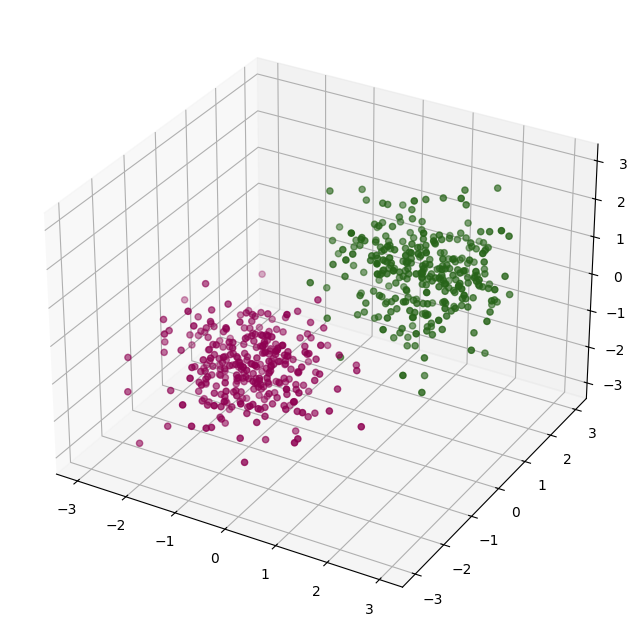

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
# Loading in the Dataset with 3 features and 1 class
# Use pandas to read the CSV file as a dataframe
df1 = pd.read_csv("blobs600.csv")

# The y values are those labelled 'Class': extract their values
y1 = df1['Class'].values

# The x values are all other columns
del df1['Class']   # drop the 'Class' column from the dataframe
X1 = df1.values     # convert the remaining columns to a numpy array

print(f"The dimensions of the dataset are: {np.shape(X1)}")

fig = plt.figure(figsize=(8, 8)) # set the size to 8x8 
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X1[:,0], X1[:,1], X1[:,2], c=y1, cmap="PiYG") # changed the colour map because why not

plt.show()
plt.close(fig)

The dimensions of Dataset 2 are: (500, 2)


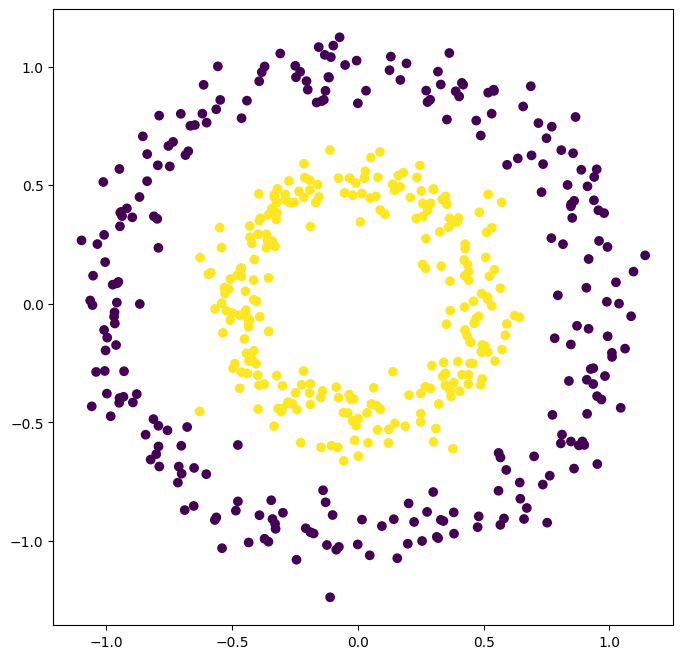

In [119]:
# Loading in the Dataset with 2 features and 1 class
# Use pandas to read the CSV file as a dataframe
df2 = pd.read_csv("circles500.csv")

# The y values are those labelled 'Class': extract their values
y2 = df2['Class'].values

# The x values are all other columns
del df2['Class']   # drop the 'Class' column from the dataframe
X2 = df2.values     # convert the remaining columns to a numpy array

print(f"The dimensions of Dataset 2 are: {np.shape(X2)}")

# plot X[0] vs X[1] and colour points according to the class, y

fig, ax = plt.subplots(figsize=(8, 8)) 

ax.scatter(X2[:,0], X2[:,1], c=y2) 

plt.show()
plt.close(fig)

In [120]:
# TASK 2: Testing on Datasets
# on testing it seems the 3D dataset is linearly separable, while the 2D dataset is not.

# initilising the models
D3valmodel = LogisticRegressionTrainer(X1, y1)
D2valmodel = LogisticRegressionTrainer(X2, y2)

In [ ]:
# TASK 2: Testing on Datasets
# on testing it seems the 3D dataset is linearly separable, while the 2D dataset is not.
from itertools import product

#hyperparameter grid to search over
param_grid = {
    "epochs": [50, 100],
    "learning_rate": [0.05, 0.1],
    "batch_size": [None, 4],
    "N": [5, 10],
    "threshold": [1e-3, 1e-4],
}

keys, values = zip(*param_grid.items())

# Generate all possible combinations
all_combinations = [dict(zip(keys, combination)) for combination in product(*values)]
results3D = []
results2D = []

# collecting top 3 results for each dataset based on validation accuracy
for i,combination in enumerate(all_combinations):
    if i == 0 or (i + 1) % 8 == 0:
        print(f"Testing combination {i+1}/{len(all_combinations)}: {combination} of Dataset 3D")
    D3valmodel.train(**combination)
    val_loss,val_acc = D3valmodel.evaluate()
    results3D.append({
        "params": combination,
        "val_loss": val_loss,
        "val_acc": val_acc
    })
    if i == 0 or (i + 1) % 8 == 0:
        print(f"Testing combination {i+1}/{len(all_combinations)}: {combination} of Dataset 2D")
    D2valmodel.train(**combination)
    val_loss,val_acc = D2valmodel.evaluate()
    results2D.append({
        "params": combination,
        "val_loss": val_loss,
        "val_acc": val_acc
    })
    D3valmodel.reset()
    D2valmodel.reset()

# Sort by descending accuracy
sorted_results3D = sorted(
    results3D,
    key=lambda r: r["val_acc"],
    reverse=True
)

sorted_results2D = sorted(
    results2D,
    key=lambda r: r["val_acc"],
    reverse=True
)

top5_3D = sorted_results3D[:3]
top5_2D = sorted_results2D[:3]

for i, r in enumerate(top5_3D):
    print(f"Top {i+1} (3D): Accuracy={r['val_acc']:.4f}, Params={r['params']}")

print()

for i, r in enumerate(top5_2D):
    print(f"Top {i+1} (2D): Accuracy={r['val_acc']:.4f}, Params={r['params']}")

# The 2D data may need a more complex model or larger search space

Testing combination 1/32: {'epochs': 50, 'learning_rate': 0.05, 'batch_size': None, 'N': 5, 'threshold': 0.001} of Dataset 3D
Testing combination 1/32: {'epochs': 50, 'learning_rate': 0.05, 'batch_size': None, 'N': 5, 'threshold': 0.001} of Dataset 2D
Testing combination 8/32: {'epochs': 50, 'learning_rate': 0.05, 'batch_size': 4, 'N': 10, 'threshold': 0.0001} of Dataset 3D
Testing combination 8/32: {'epochs': 50, 'learning_rate': 0.05, 'batch_size': 4, 'N': 10, 'threshold': 0.0001} of Dataset 2D
Testing combination 16/32: {'epochs': 50, 'learning_rate': 0.1, 'batch_size': 4, 'N': 10, 'threshold': 0.0001} of Dataset 3D
Testing combination 16/32: {'epochs': 50, 'learning_rate': 0.1, 'batch_size': 4, 'N': 10, 'threshold': 0.0001} of Dataset 2D
Testing combination 24/32: {'epochs': 100, 'learning_rate': 0.05, 'batch_size': 4, 'N': 10, 'threshold': 0.0001} of Dataset 3D
Testing combination 24/32: {'epochs': 100, 'learning_rate': 0.05, 'batch_size': 4, 'N': 10, 'threshold': 0.0001} of Datas

In [104]:
D3valmodel.reset()
D2valmodel.reset()

In [105]:
D3valmodel.train(**top5_3D[0]['params']) 
D2valmodel.train(**top5_2D[0]['params']) 

d3loss, d3acc = D3valmodel.evaluate_test()
d2loss, d2acc = D2valmodel.evaluate_test()
print(f"3D Dataset - Loss: {d3loss}, Accuracy: {d3acc}")
print(f"2D Dataset - Loss: {d2loss}, Accuracy: {d2acc}")

3D Dataset - Loss: 0.2133, Accuracy: 97.77777777777777
2D Dataset - Loss: 0.693, Accuracy: 53.333333333333336


In [109]:
newy1 = D3valmodel.predict(X1)
newy2 = D2valmodel.predict(X2)

df1_pred = pd.DataFrame(X1, columns=['Feature1', 'Feature2', 'Feature3'])
df1_pred['Predicted'] = newy1  # add predictions as a new column

# For the 2-feature dataset
df2_pred = pd.DataFrame(X2, columns=['Feature1', 'Feature2'])
df2_pred['Predicted'] = newy2  # add predictions as a new column

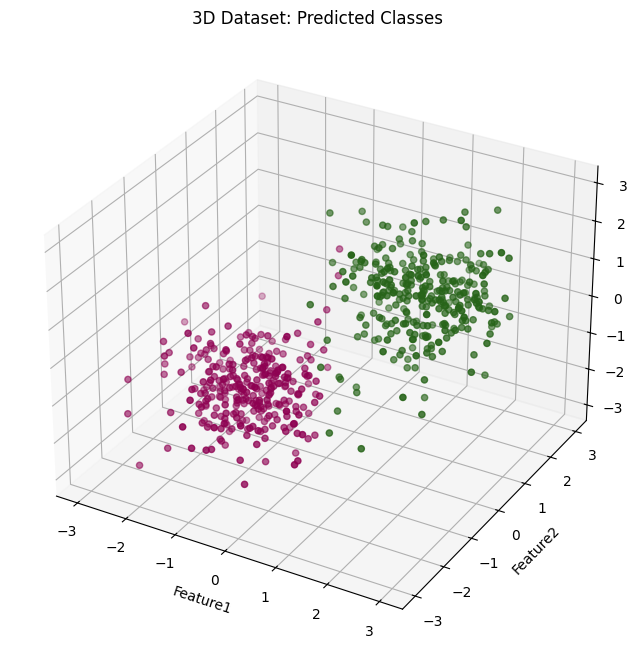

In [110]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df1_pred['Feature1'], 
    df1_pred['Feature2'], 
    df1_pred['Feature3'], 
    c=df1_pred['Predicted'],  # color by predicted class
    cmap='PiYG'
)

ax.set_xlabel('Feature1')
ax.set_ylabel('Feature2')
ax.set_zlabel('Feature3')
ax.set_title('3D Dataset: Predicted Classes')

plt.show()
plt.close(fig)

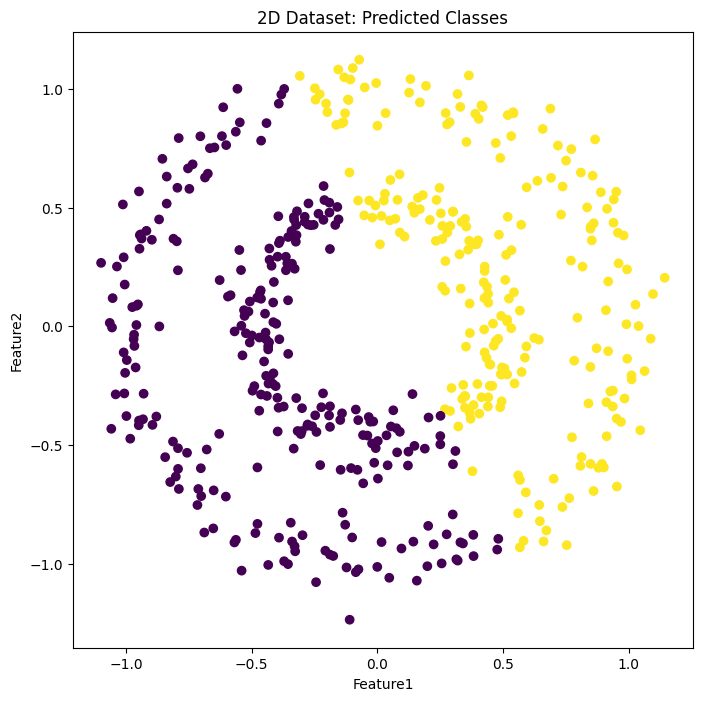

In [112]:
plt.figure(figsize=(8, 8))

plt.scatter(
    df2_pred['Feature1'], 
    df2_pred['Feature2'], 
    c=df2_pred['Predicted'],  # color by predicted class
)

plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.title('2D Dataset: Predicted Classes')
plt.show()

In [127]:
# TASK 3: Adding a hidden layer
# I will be keeping the best hyperparameters found in the previous task and adding more neurons to hidden layers.
# I recognise that that there may a better way using K-fold cross validation but the iterations take too much time to run.
# I will be assuming that those hyperparameeters are close to the optimal unless i get extremely poor results. I will also only test the 2D dataset as it is the only one with possible improvements.

hiddenLayerSet = [4, 8, 16, 32, 64]

for i in hiddenLayerSet:
    D2valmodel.reset(hidden_layers=[i,1],val_ratio=0)
    D2valmodel.train(**top5_2D[0]['params'])
    val,acc = D2valmodel.evaluate_test()
    print(f"Hidden Layer Size: {i}, Test Accuracy: {acc:.4f}")

Hidden Layer Size: 4, Test Accuracy: 58.0000
Hidden Layer Size: 8, Test Accuracy: 66.6667
Hidden Layer Size: 16, Test Accuracy: 46.6667
Hidden Layer Size: 32, Test Accuracy: 88.0000
Hidden Layer Size: 64, Test Accuracy: 96.6667


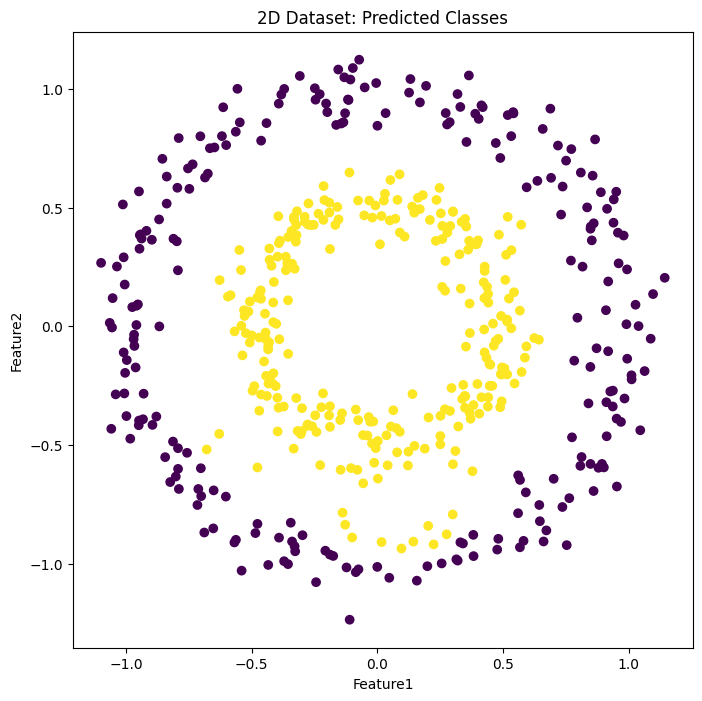

In [129]:
newy2 = D2valmodel.predict(X2)
df2_pred = pd.DataFrame(X2, columns=['Feature1', 'Feature2'])
df2_pred['Predicted'] = newy2  # add predictions as a new column

plt.figure(figsize=(8, 8))

plt.scatter(
    df2_pred['Feature1'], 
    df2_pred['Feature2'], 
    c=df2_pred['Predicted'],  # color by predicted class
)

plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.title('2D Dataset: Predicted Classes')
plt.show()

In [7]:
# TASK 4: Testing on EMNIST Dataset

data = np.load("emnist_letters_85800.npz")

x_data = data["x"]
y_data = data["y"]

In [8]:
# Do some data checks ...

# Check how many different classes we have: should be 26
n_classes =len(np.unique(y_data))
print(f"The number of unique classes is {n_classes} (should be 26).")

# check that images are scaled: min should be 0, max should be 1
img = x_data[0]
print(f"\nFor a single image, the min value is {img.min()} and the max is {img.max()} (should be 0.0 and 1.0).")

# Check the shape of the two classes
print(f"\nShape of x_data is {x_data.shape}, shape of y_data is {y_data.shape} (should have 85,800 cases and x should be 28x28).")

The number of unique classes is 26 (should be 26).

For a single image, the min value is 0.0 and the max is 1.0 (should be 0.0 and 1.0).

Shape of x_data is (85800, 28, 28, 1), shape of y_data is (85800,) (should have 85,800 cases and x should be 28x28).


In [9]:
# Extract just two classes from the dataset

# PUT YOUR OWN CLASS NUMBERS HERE: remember that A=1, z=26.
c1 = 21   # U
c2 = 23  # W

mask = (y_data == c1) | (y_data == c2)

x_binary = x_data[mask]
y_binary = y_data[mask]

# Now change labels to 0 and 1
y_binary = (y_binary == c2).astype(int)

In [10]:
print(x_binary.shape, y_binary.shape)

(6600, 28, 28, 1) (6600,)


In [11]:
x_flat = x_binary.reshape(x_binary.shape[0], 28*28)  # shape -> (85800, 784)
x_flat_bin = (x_flat >= 0).astype(int)
print(x_flat_bin.shape)

(6600, 784)


In [9]:
EMnistvalmodel = LogisticRegressionTrainer(x_flat_bin, y_binary, hidden_layers=[8,1])
EMnistvalmodel.reset(train_ratio=0.8, val_ratio=0)
losses, accuracies = EMnistvalmodel.train(epochs=50, learning_rate=0.1, batch_size=64, N=10, threshold=1e-3, verbose=True)
emval,emacc = EMnistvalmodel.evaluate_test()
print(f"EMNIST Binary Dataset - Loss: {emval}, Accuracy: {emacc}")

step 1 loss 3.3827, accuracy 53.12%
step 2 loss 1.8333, accuracy 60.94%
step 3 loss 2.1958, accuracy 53.12%
step 4 loss 1.5681, accuracy 51.56%
step 5 loss 1.2348, accuracy 59.38%
step 6 loss 1.2340, accuracy 57.81%
step 7 loss 0.9640, accuracy 62.50%
step 8 loss 1.4141, accuracy 64.06%
step 9 loss 0.9225, accuracy 60.94%
step 10 loss 0.7965, accuracy 71.88%
step 11 loss 0.8397, accuracy 71.88%
step 12 loss 0.7995, accuracy 67.19%
step 13 loss 0.9036, accuracy 54.69%
step 14 loss 0.6164, accuracy 73.44%
step 15 loss 0.7421, accuracy 67.19%
step 16 loss 0.7229, accuracy 64.06%
step 17 loss 0.6560, accuracy 65.62%
step 18 loss 0.6748, accuracy 64.06%
step 19 loss 0.6480, accuracy 65.62%
step 20 loss 0.7335, accuracy 67.19%
step 21 loss 0.6758, accuracy 65.62%
step 22 loss 0.5899, accuracy 73.44%
step 23 loss 0.7904, accuracy 56.25%
step 24 loss 0.6516, accuracy 68.75%
step 25 loss 0.5519, accuracy 73.44%
step 26 loss 0.6391, accuracy 65.62%
step 27 loss 0.8012, accuracy 65.62%
step 28 lo

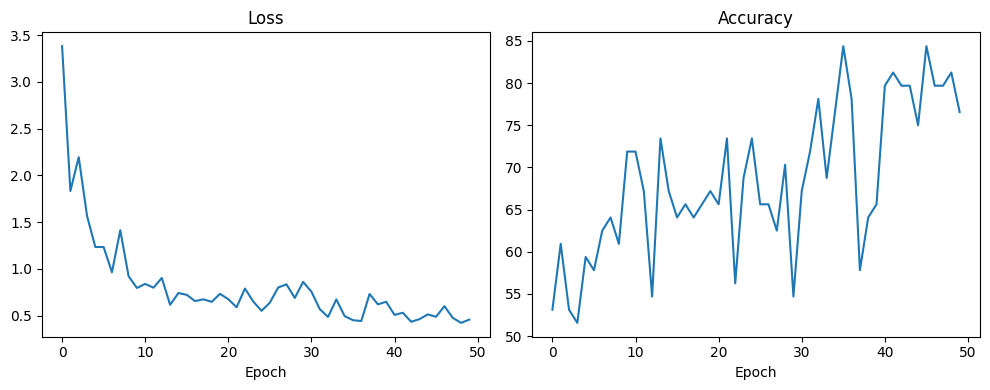

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Loss")
plt.xlabel("Epoch")

plt.subplot(1, 2, 2)
plt.plot(accuracies)
plt.title("Accuracy")
plt.xlabel("Epoch")

plt.tight_layout()
plt.show()

# From the spikes in Accuracy i dont think the model is converging, and it may need more epochs or a different learning rate.
# It can be also that the hypothesis language is not complex enough and we may need more layers to be able to represent the data well.
# i will also add L2 regularization to see if it can help with convergence and generalization. and move all greyscale values to 1

In [13]:
EMnistvalmodel.reset(train_ratio=0.8, val_ratio=0)

In [12]:
EMnistvalmodelV2 = LogisticRegressionTrainer(x_flat_bin, y_binary, hidden_layers=[32,16,1])
EMnistvalmodelV2.reset(train_ratio=0.8, val_ratio=0)
losses, accuracies = EMnistvalmodelV2.train(epochs=100, learning_rate=0.05, batch_size=32, N=10, threshold=1e-4, verbose=True)
emval,emacc = EMnistvalmodelV2.evaluate_test()
print(f"EMNIST Binary Dataset - Loss: {emval}, Accuracy: {emacc}")

step 1 loss 8.5627, accuracy 46.88%
step 2 loss 7.5554, accuracy 53.12%
step 3 loss 8.0590, accuracy 50.00%
step 4 loss 10.0738, accuracy 37.50%
step 5 loss 7.5554, accuracy 53.12%
step 6 loss 7.0517, accuracy 56.25%
step 7 loss 9.5701, accuracy 40.62%
step 8 loss 5.5406, accuracy 65.62%
step 9 loss 7.5554, accuracy 53.12%
step 10 loss 10.0738, accuracy 37.50%
step 11 loss 9.5701, accuracy 40.62%
step 12 loss 5.5406, accuracy 65.62%
step 13 loss 8.5627, accuracy 46.88%
step 14 loss 10.0738, accuracy 37.50%
step 15 loss 7.0517, accuracy 56.25%
step 16 loss 9.5701, accuracy 40.62%
step 17 loss 7.5554, accuracy 53.12%
step 18 loss 10.0738, accuracy 37.50%
step 19 loss 9.5701, accuracy 40.62%
step 20 loss 4.5332, accuracy 71.88%
step 21 loss 8.5627, accuracy 46.88%
step 22 loss 8.0590, accuracy 50.00%
step 23 loss 8.5627, accuracy 46.88%
step 24 loss 7.5554, accuracy 53.12%
step 25 loss 6.5480, accuracy 59.38%
step 26 loss 9.5701, accuracy 40.62%
step 27 loss 8.5627, accuracy 46.88%
step 2

KeyboardInterrupt: 

In [11]:
EMnistvalmodelV2.reset(train_ratio=0.8, val_ratio=0)

In [6]:
import sys
sys.setrecursionlimit(100000)